In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/facial-key-point-data/all_data.json
/kaggle/input/facial-key-point-data/images/01301.png
/kaggle/input/facial-key-point-data/images/02578.png
/kaggle/input/facial-key-point-data/images/00929.png
/kaggle/input/facial-key-point-data/images/04915.png
/kaggle/input/facial-key-point-data/images/02630.png
/kaggle/input/facial-key-point-data/images/03862.png
/kaggle/input/facial-key-point-data/images/01883.png
/kaggle/input/facial-key-point-data/images/00704.png
/kaggle/input/facial-key-point-data/images/03163.png
/kaggle/input/facial-key-point-data/images/01124.png
/kaggle/input/facial-key-point-data/images/04159.png
/kaggle/input/facial-key-point-data/images/01570.png
/kaggle/input/facial-key-point-data/images/03092.png
/kaggle/input/facial-key-point-data/images/03663.png
/kaggle/input/facial-key-point-data/images/04084.png
/kaggle/input/facial-key-point-data/images/04216.png
/kaggle/input/facial-key-point-data/images/02640.png
/kaggle/input/facial-key-point-data/images/02422.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prashantarorat/facial-key-point-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/facial-key-point-data


In [3]:
import os
dataset_path = '/kaggle/input/facial-key-point-data'

In [4]:
os.listdir(dataset_path)

['all_data.json', 'images']

In [5]:
images_path = '/kaggle/input/facial-key-point-data/images'
json_path = '/kaggle/input/facial-key-point-data/all_data.json'

In [7]:
os.listdir(images_path)[:5]

['01301.png', '02578.png', '00929.png', '04915.png', '02630.png']

In [8]:
import json

with open(json_path, 'r') as f:
    data = json.load(f)

# Print the type and the first item to understand structure
print(f"Data Type: {type(data)}")

if isinstance(data, list):
    print("First item:", data[0])
elif isinstance(data, dict):
    # Print first key-value pair
    first_key = next(iter(data))
    print(f"First Key: {first_key}")
    print(f"First Value: {data[first_key]}")

Data Type: <class 'dict'>
First Key: 0
First Value: {'file_name': '00000.png', 'face_landmarks': [[73.7203007518797, 237.71428571428572], [81.03458646616541, 276.2105263157895], [88.34887218045112, 312.78195488721803], [102.20751879699247, 347.81353383458645], [128.0, 375.1458646616541], [161.10676691729324, 393.2390977443609], [198.44812030075187, 405.17293233082705], [229.63007518796994, 418.26165413533835], [259.27218045112784, 420.57142857142856], [284.29473684210524, 412.8721804511278], [305.46766917293235, 396.70375939849623], [329.7203007518797, 381.30526315789473], [349.73834586466165, 357.82255639097747], [362.0571428571429, 329.33533834586467], [366.6766917293233, 298.53834586466166], [367.44661654135336, 267.74135338345866], [367.8315789473684, 237.3293233082707], [134.1593984962406, 211.9218045112782], [158.02706766917294, 196.13834586466166], [188.05413533834587, 188.05413533834587], [221.1609022556391, 188.82406015037594], [250.03308270676692, 197.29323308270676], [284.67

In [9]:
import os
import torch
from torch.utils.data import Dataset
import json
import numpy as np
from PIL import Image
from torchvision import transforms

class FacialKeypointsJSONDataset(Dataset):
    def __init__(self, json_file, root_dir, output_size=(224, 224)):
        self.root_dir = root_dir
        self.output_size = output_size
        
        # Load the JSON data
        with open(json_file, 'r') as f:
            self.data = json.load(f)
            
        # FIX 1: Your JSON is a dictionary {"0": {...}, "1": {...}}
        # We just want the list of values: [{...}, {...}]
        # This automatically handles the conversion from "0" -> {obj}
        self.data_list = list(self.data.values())

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        # This gets the object: {"file_name": "00000.png", "face_landmarks": [...]}
        item = self.data_list[idx]

        # FIX 2: Use the EXACT keys shown in your screenshot
        img_filename = item['file_name']      # Directly gets "00000.png"
        raw_points = item['face_landmarks']   # Directly gets the list of 68 points

        # 1. Load Image
        img_path = os.path.join(self.root_dir, img_filename)
        
        # Safety check: Ensure file exists before opening
        if not os.path.exists(img_path):
             raise FileNotFoundError(f"Looking for {img_path} but not found.")
             
        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size

        # 2. Process Points (Standard logic from here on)
        key_pts = np.array(raw_points, dtype='float32').reshape(-1, 2)

        # 3. Resize Image
        new_h, new_w = self.output_size
        image = image.resize((new_w, new_h))
        
        # 4. Scale Points
        key_pts[:, 0] = key_pts[:, 0] * (new_w / orig_w)
        key_pts[:, 1] = key_pts[:, 1] * (new_h / orig_h)
        
        # 5. Normalize Points [0, 1]
        key_pts[:, 0] = key_pts[:, 0] / new_w
        key_pts[:, 1] = key_pts[:, 1] / new_h
        
        # 6. To Tensor
        image = transforms.ToTensor()(image)
        image = self.normalize(image)
        key_pts = torch.from_numpy(key_pts).flatten()

        return {'image': image, 'keypoints': key_pts}

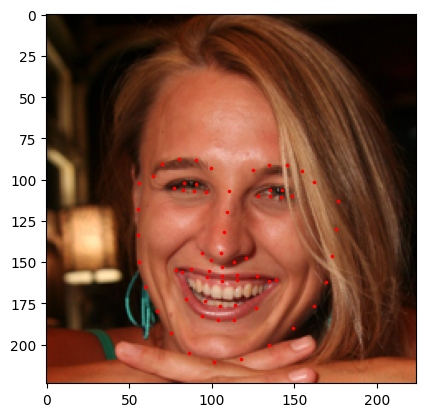

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Instantiate your new dataset
dataset = FacialKeypointsJSONDataset(json_file=json_path, root_dir=images_path)

def show_keypoints(image, keypoints):
    """
    Visualizes an image with its corresponding facial keypoints.
    
    Args:
        image (tensor): The image tensor from the dataset. 
                        Shape: [3, 224, 224] (Channels, Height, Width)
        keypoints (tensor): The flattened keypoints tensor.
                            Shape: [136] (assuming 68 landmarks * 2 coords)
    """
    
    # --- 1. PREPARE IMAGE FOR MATPLOTLIB ---
    
    # Convert PyTorch Tensor to a NumPy array because Matplotlib cannot plot Tensors.
    # Then, Transpose the dimensions.
    # PyTorch format: [Channels, Height, Width] (e.g., 3, 224, 224)
    # Matplotlib format: [Height, Width, Channels] (e.g., 224, 224, 3)
    # (1, 2, 0) moves dimension 1 (Height) to pos 0, dim 2 (Width) to pos 1, and dim 0 (Channels) to pos 2.
    image = image.numpy().transpose((1, 2, 0))

    # --- 2. DENORMALIZE IMAGE COLORS ---
    
    # We normalized the image in the Dataset class using ImageNet stats:
    # formula: input = (input - mean) / std
    # To view it normally, we must reverse this: input = (input * std) + mean
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Apply the reverse formula. 
    # Broadcasting happens here: numpy automatically applies these 3 values to the 3 channels of every pixel.
    image = std * image + mean
    
    # Clip values to ensure they stay strictly between 0 and 1.
    # Floating point math can sometimes result in 1.000001 or -0.000001, 
    # which causes Matplotlib to throw a warning or error.
    image = np.clip(image, 0, 1)
    
    # Plot the image foundation
    plt.imshow(image)
    
    # --- 3. PREPARE AND PLOT KEYPOINTS ---
    
    # The dataset outputs a flat list (Shape: 136) for the model's Linear layer.
    # For plotting (x, y), we need to reshape it back to pairs (Shape: 68, 2).
    # '-1' tells numpy to figure out the number of rows automatically based on the data size.
    keypoints = keypoints.numpy().reshape(-1, 2)
    
    # Denormalize the coordinates.
    # In the Dataset class, we divided x/width and y/height to get values between [0, 1].
    # Now we multiply by 224 (our image size) to get back to actual Pixel Coordinates (e.g., x=112, y=50).
    # Note: If your image size isn't 224, change this number!
    keypoints = keypoints * 224 
    
    # Scatter plot the points on top of the image.
    # keypoints[:, 0] selects all rows, 0th column (X coordinates).
    # keypoints[:, 1] selects all rows, 1st column (Y coordinates).
    # s=10 is size of dot, c='r' is color red.
    plt.scatter(keypoints[:, 0], keypoints[:, 1], s=10, marker='.', c='r')
    
    # Render the final plot
    plt.show()

# --- EXECUTION ---

# Fetch the first sample from the dataset class (calls __getitem__)
# This returns a dictionary: {'image': tensor, 'keypoints': tensor}
sample = dataset[1] 

# Pass the tensors to our function
show_keypoints(sample['image'], sample['keypoints'])

In [11]:
import torch
import torch.nn as nn
import torchvision.models as models

def get_model():
    # 1. Load Pretrained ResNet18
    model = models.resnet18(pretrained=True)
    
    # 2. Freeze the early layers (Optional but recommended for speed/stability)
    # This prevents us from "breaking" the pre-trained features early on.
    for param in model.parameters():
        param.requires_grad = False
        
    # 3. Modify the Head
    # ResNet18's last layer (fc) sees 512 features. We need 136 outputs.
    # We unfreeze these new layers so they can learn.
    model.fc = nn.Sequential(
        nn.Linear(512, 136), # 68 points * 2 coordinates = 136
        nn.Sigmoid()         # Forces output between 0 and 1
    )
    
    return model

# Initialize model and move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model().to(device)

print(f"Model loaded on: {device}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s] 


Model loaded on: cuda


In [21]:
from torch.utils.data import DataLoader, random_split

# --- 1. SETUP DATALOADERS ---
# Split dataset: 80% Train, 20% Validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,num_workers=16)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,num_workers=16)

# --- 2. LOSS & OPTIMIZER ---
criterion = nn.L1Loss() # L1 Loss is often better for keypoints than MSE
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001) 
# Note: We are only optimizing model.fc parameters initially!

In [22]:
# --- 3. TRAINING LOOP ---
num_epochs = 15
print("Starting Training...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for i, batch in enumerate(train_loader):
        # Move data to GPU
        images = batch['image'].to(device)
        keypoints = batch['keypoints'].to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        
        # Calculate loss
        loss = criterion(outputs, keypoints)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if (i+1) % 10 == 0: # Print every 10 batches
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    # Validation Step (Optional but good practice)
    val_loss = 0.0
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            keypoints = batch['keypoints'].to(device)
            outputs = model(images)
            val_loss += criterion(outputs, keypoints).item()
    
    print(f"--> Epoch {epoch+1} Complete. Avg Val Loss: {val_loss/len(val_loader):.4f}")

Starting Training...
Epoch [1/15], Step [10/125], Loss: 0.0395
Epoch [1/15], Step [20/125], Loss: 0.0313
Epoch [1/15], Step [30/125], Loss: 0.0262
Epoch [1/15], Step [40/125], Loss: 0.0246
Epoch [1/15], Step [50/125], Loss: 0.0233
Epoch [1/15], Step [60/125], Loss: 0.0269
Epoch [1/15], Step [70/125], Loss: 0.0237
Epoch [1/15], Step [80/125], Loss: 0.0265
Epoch [1/15], Step [90/125], Loss: 0.0267
Epoch [1/15], Step [100/125], Loss: 0.0265
Epoch [1/15], Step [110/125], Loss: 0.0254
Epoch [1/15], Step [120/125], Loss: 0.0259
--> Epoch 1 Complete. Avg Val Loss: 0.0265
Epoch [2/15], Step [10/125], Loss: 0.0239
Epoch [2/15], Step [20/125], Loss: 0.0250
Epoch [2/15], Step [30/125], Loss: 0.0234
Epoch [2/15], Step [40/125], Loss: 0.0291
Epoch [2/15], Step [50/125], Loss: 0.0268
Epoch [2/15], Step [60/125], Loss: 0.0232
Epoch [2/15], Step [70/125], Loss: 0.0228
Epoch [2/15], Step [80/125], Loss: 0.0255
Epoch [2/15], Step [90/125], Loss: 0.0294
Epoch [2/15], Step [100/125], Loss: 0.0264
Epoch [2

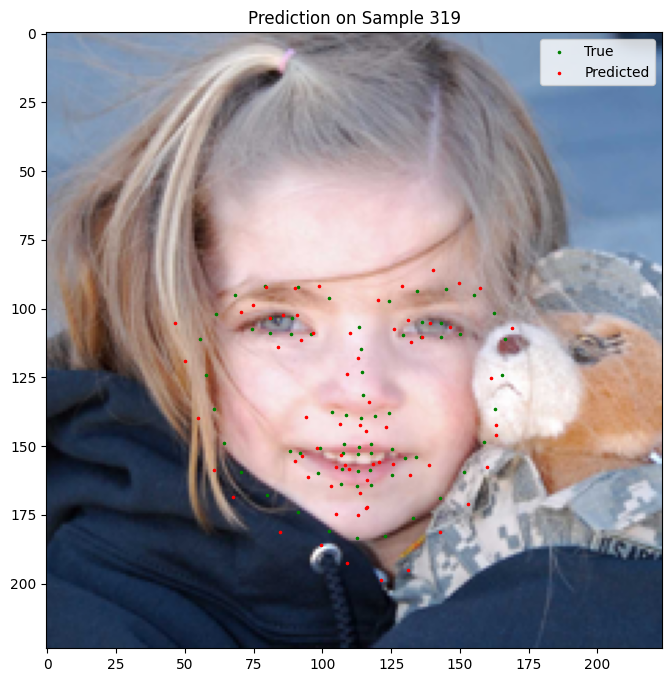

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_prediction(model, dataset):
    model.eval() # Set to evaluation mode
    
    # 1. Get a random sample from the validation dataset
    idx = np.random.randint(0, len(dataset))
    sample = dataset[idx]
    
    image_tensor = sample['image'].unsqueeze(0).to(device) # Add batch dimension: [1, 3, 224, 224]
    true_keypoints = sample['keypoints'].numpy().reshape(-1, 2)
    
    # 2. Get Prediction
    with torch.no_grad():
        predicted_keypoints = model(image_tensor)
        
    # 3. Process Prediction for Plotting
    predicted_keypoints = predicted_keypoints.cpu().numpy().reshape(-1, 2)
    
    # 4. Denormalize everything
    # Image
    image = sample['image'].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)
    
    # Keypoints (Scale 0-1 back to 0-224)
    true_keypoints = true_keypoints * 224
    predicted_keypoints = predicted_keypoints * 224
    
    # 5. Plot
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.scatter(true_keypoints[:, 0], true_keypoints[:, 1], s=10, c='g', marker='.', label='True')
    plt.scatter(predicted_keypoints[:, 0], predicted_keypoints[:, 1], s=10, c='r', marker='.', label='Predicted')
    plt.legend()
    plt.title(f"Prediction on Sample {idx}")
    plt.show()

# Run this multiple times to see different faces!
visualize_prediction(model, val_dataset)